In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/heart-disease-risk-2026/heart_disease_risk_2026.csv


## DATA OVERVIEW

In [2]:
df=pd.read_csv('/kaggle/input/datasets/uditjain13/heart-disease-risk-2026/heart_disease_risk_2026.csv')
df

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,8996,36,Female,108,63,178,68,82,158,96,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,Female,112,73,213,54,139,102,125,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,Female,144,93,198,66,113,79,102,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,Female,130,70,220,68,135,109,104,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

**The dataset is made up of 9000 entries and 27 columns overall.**

In [4]:
df.describe()

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,...,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,...,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,1.000000,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,...,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,...,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,...,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,...,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,9000.000000,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,...,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

**No duplicate entries.**

In [6]:
df.isnull().sum()

patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

**No null entries either.**

## EDA

In [7]:
df['has_heart_disease'].value_counts()

has_heart_disease
0    6273
1    2727
Name: count, dtype: int64

**The dataset target variable, 'has heart disease' is made up of 6273 people not having a heart disease and 2727 people having a heart disease.**

In [8]:
df.drop(columns='patient_id', inplace=True)

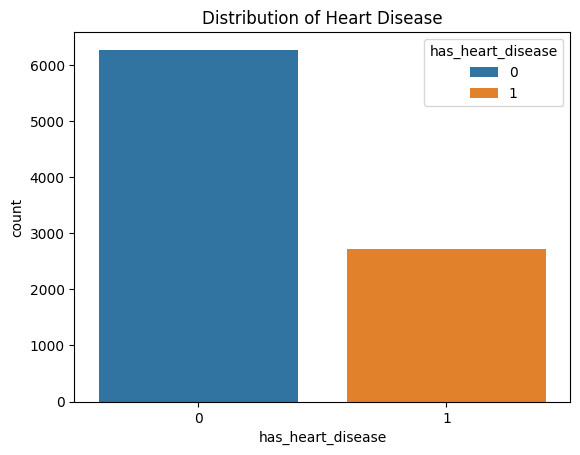

In [9]:
sns.countplot(data=df,x='has_heart_disease', hue='has_heart_disease')
plt.title("Distribution of Heart Disease")
plt.show()

In [10]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object','bool']).columns

print(num_cols)
print(cat_cols)

Index(['age', 'resting_bp_systolic', 'resting_bp_diastolic',
       'cholesterol_total', 'hdl', 'ldl', 'triglycerides',
       'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate',
       'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week',
       'exercise_minutes_per_week', 'sleep_hours', 'stress_score',
       'daily_steps', 'diet_quality_score', 'has_heart_disease'],
      dtype='object')
Index(['sex', 'chest_pain_type', 'exercise_induced_angina', 'family_history',
       'smoker_status', 'wearable_owner'],
      dtype='object')


**Just shows all the numerical and categorical columns in separate lists.**

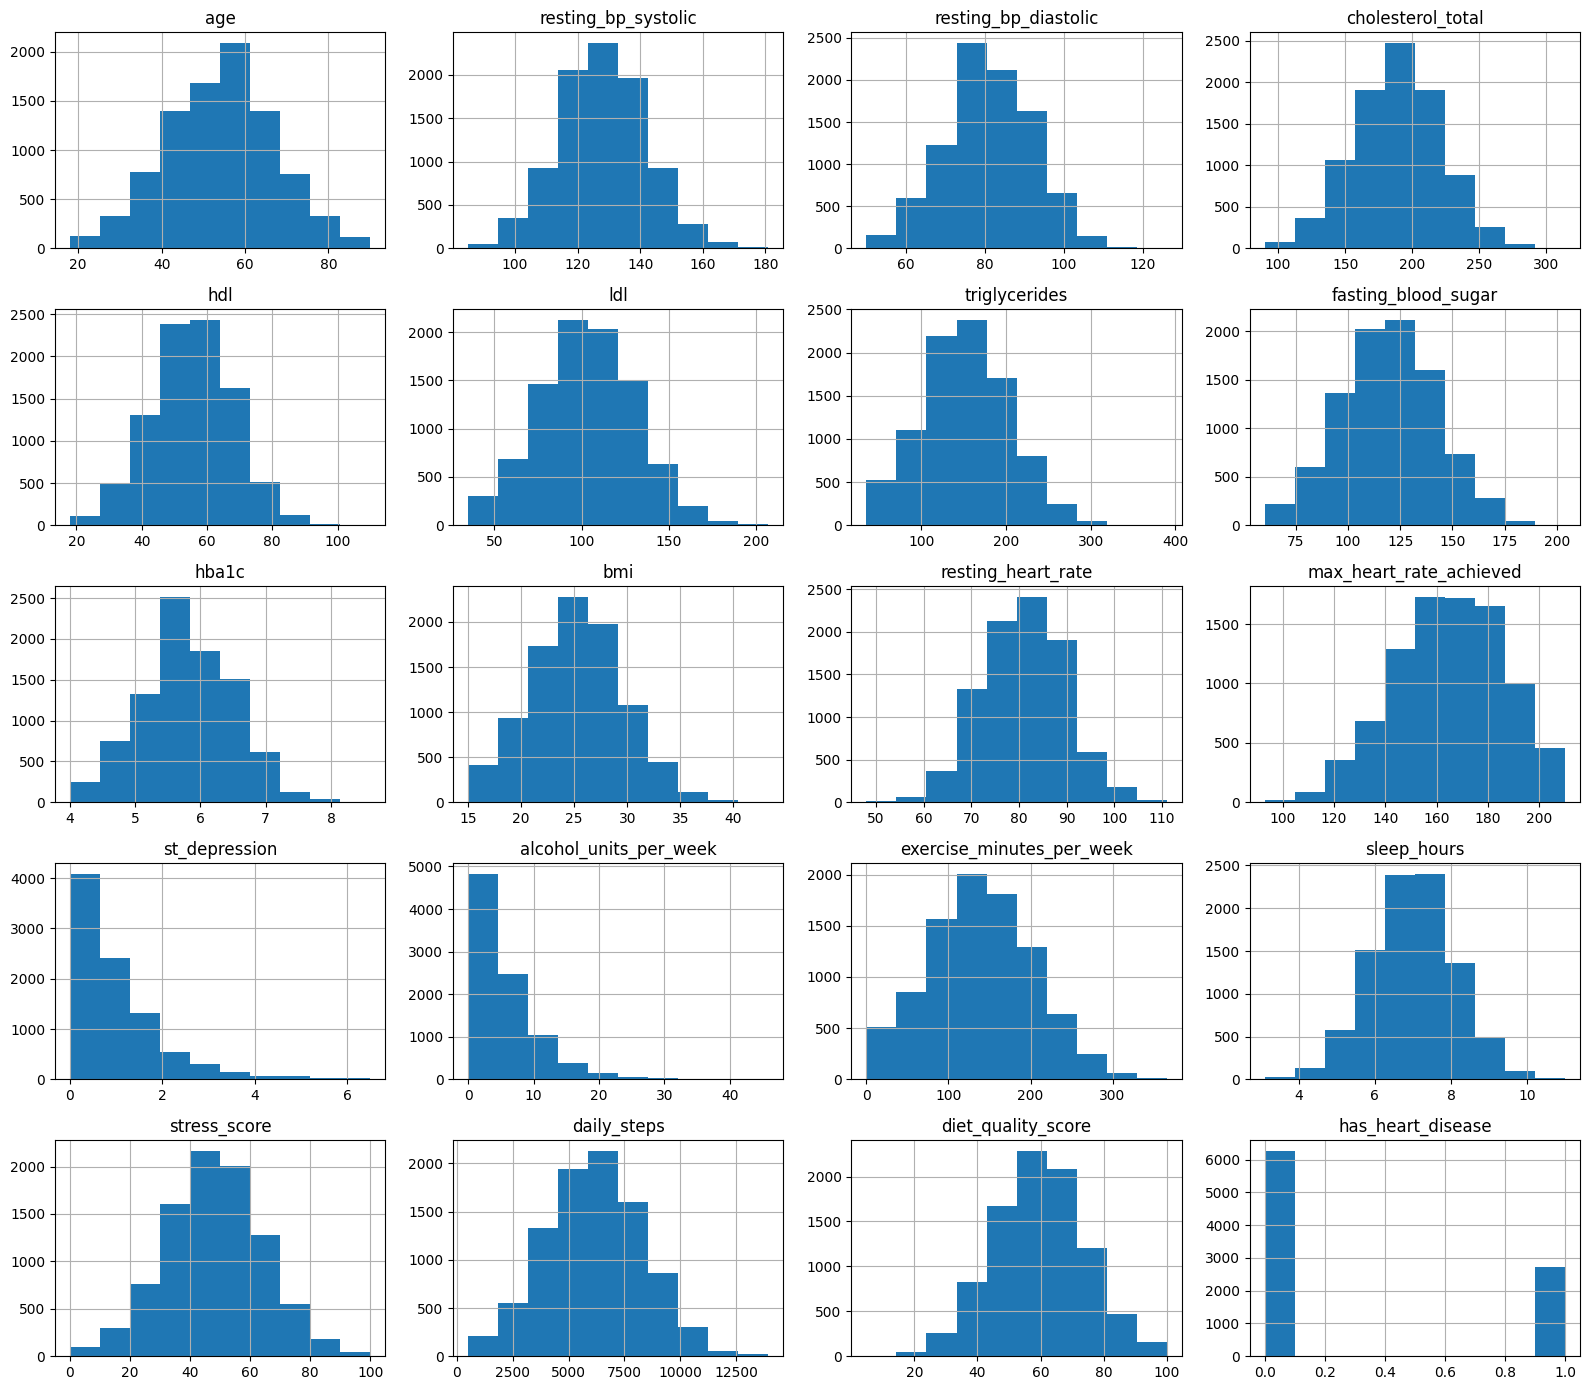

In [11]:
df[num_cols].hist(figsize=(16,14))
plt.tight_layout()

1. st_depression and alcohol_units_per_week are positively skewed with long tails trailing towards right.
2. The rest of the measurements do now show any unusual patterns, hence falling within normal and acceptable ranges.
3. No other severe anomalies or such were found just through these graphs alone. 

In [12]:
df.skew(numeric_only=True)

age                         -0.021674
resting_bp_systolic          0.067686
resting_bp_diastolic         0.008614
cholesterol_total            0.003850
hdl                          0.020459
ldl                          0.044963
triglycerides                0.125859
fasting_blood_sugar          0.040870
hba1c                        0.029182
bmi                          0.091722
resting_heart_rate          -0.018912
max_heart_rate_achieved     -0.184662
exercise_induced_angina      1.289361
st_depression                2.040911
family_history               1.022393
alcohol_units_per_week       2.027234
exercise_minutes_per_week    0.093647
sleep_hours                 -0.042455
stress_score                -0.012987
wearable_owner               0.230441
daily_steps                  0.024890
diet_quality_score           0.001227
has_heart_disease            0.857494
dtype: float64

**Most values are very close to zero, indicating that they are mostly symmetric in nature. The columns which have slightly negative skewness like age, sleep hours, stress score etc, are also very close to zero, indicating that they are only very slightly skewed. st_depression and alcohol_units_per_week have a high positive skew value, indicating what we already found in the histograms above, positively skewed with a long right tail.**

In [13]:
df.kurt(numeric_only=True)

age                         -0.205503
resting_bp_systolic          0.029089
resting_bp_diastolic        -0.079739
cholesterol_total           -0.028042
hdl                         -0.031527
ldl                         -0.098520
triglycerides               -0.024352
fasting_blood_sugar         -0.140283
hba1c                       -0.076007
bmi                         -0.122467
resting_heart_rate          -0.016484
max_heart_rate_achieved     -0.368012
exercise_induced_angina     -0.337623
st_depression                5.606419
family_history              -0.954925
alcohol_units_per_week       6.288431
exercise_minutes_per_week   -0.229501
sleep_hours                 -0.030894
stress_score                -0.013838
wearable_owner              -1.947330
daily_steps                 -0.134160
diet_quality_score          -0.076935
has_heart_disease           -1.264986
dtype: float64

**Most of the columns are again very close to zero, hence they are not very tail heavy and do not contain as many extreme values/observations. st_depression and alcohol_units_per_week have a very high positive value, indicating a high tail heaviness and a very high possibility of extreme values or *outliers* being present.**

In [14]:
print(num_cols)

Index(['age', 'resting_bp_systolic', 'resting_bp_diastolic',
       'cholesterol_total', 'hdl', 'ldl', 'triglycerides',
       'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate',
       'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week',
       'exercise_minutes_per_week', 'sleep_hours', 'stress_score',
       'daily_steps', 'diet_quality_score', 'has_heart_disease'],
      dtype='object')


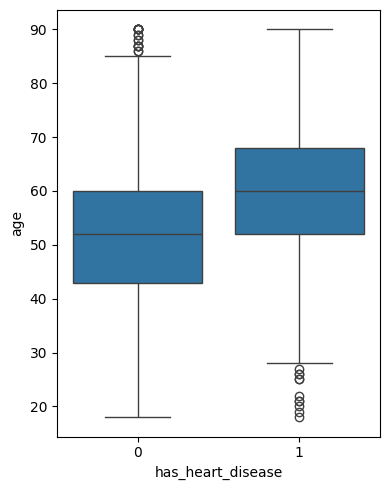

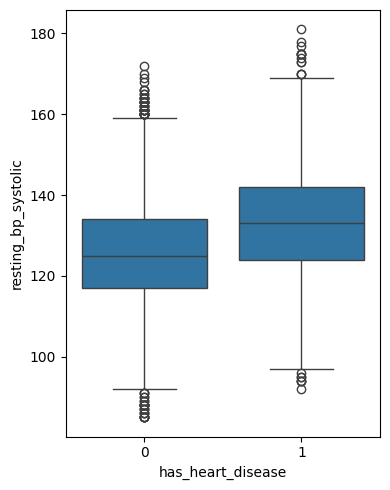

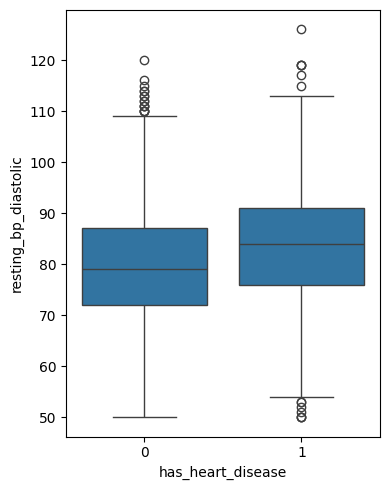

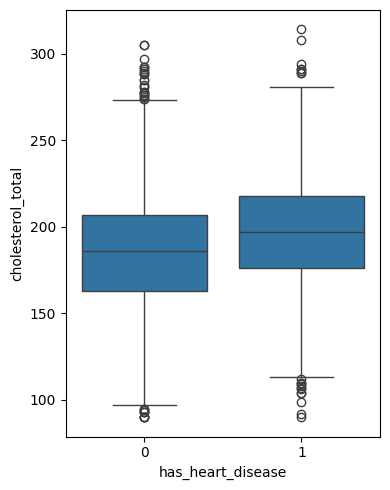

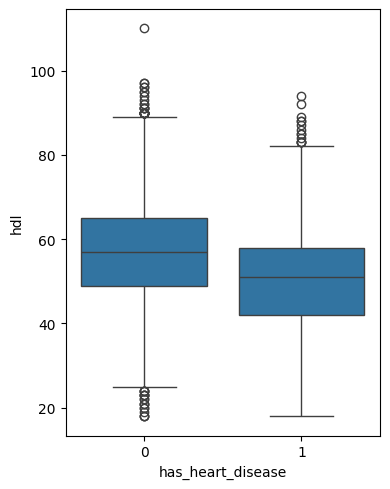

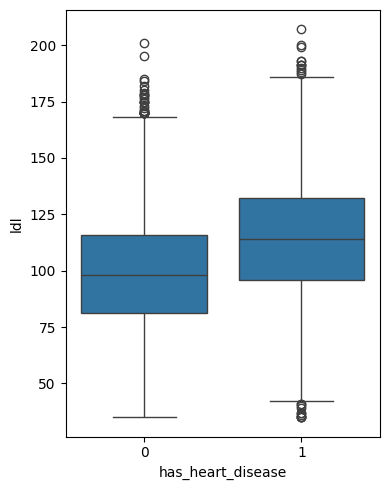

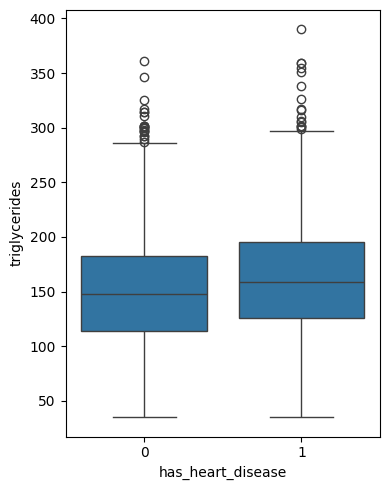

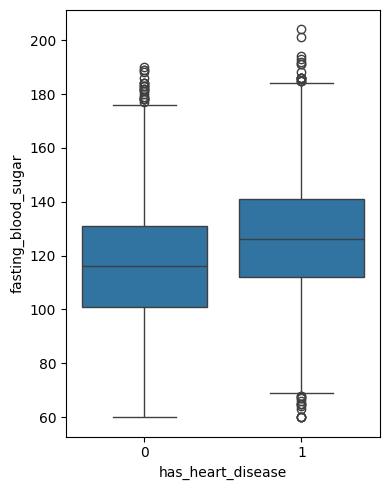

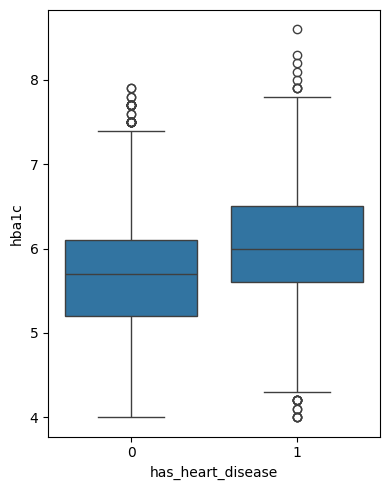

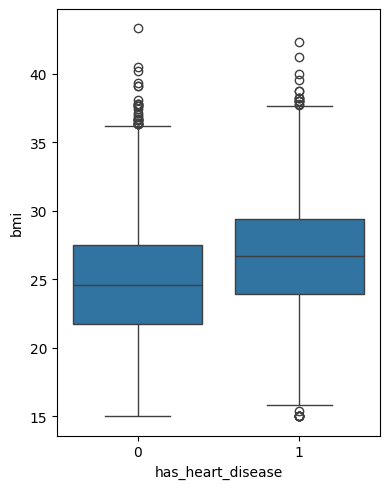

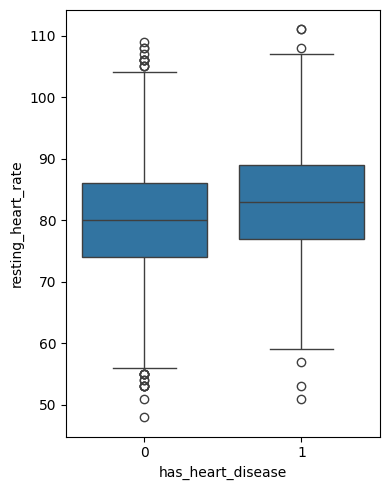

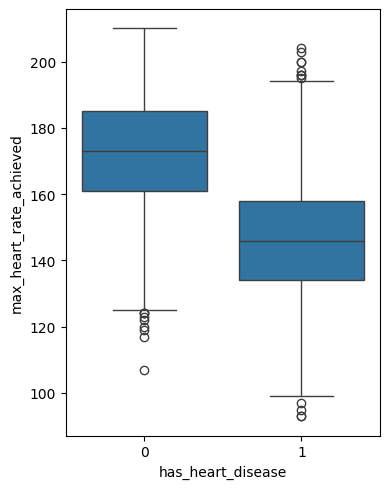

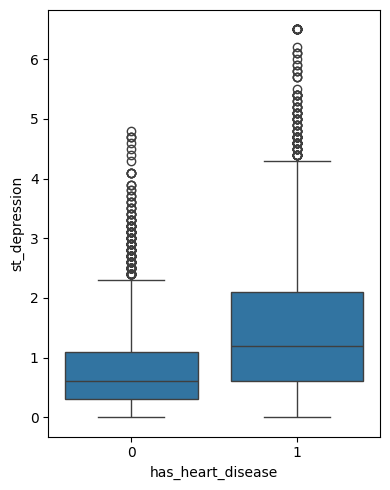

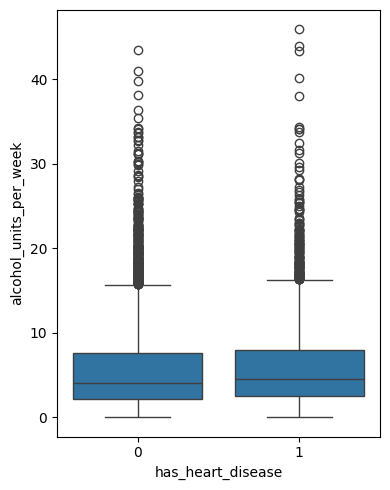

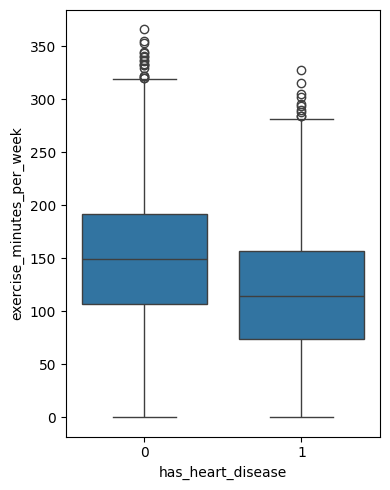

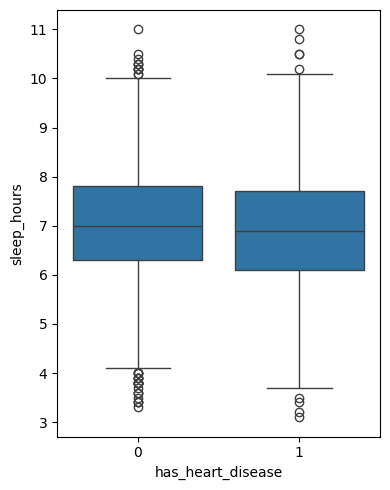

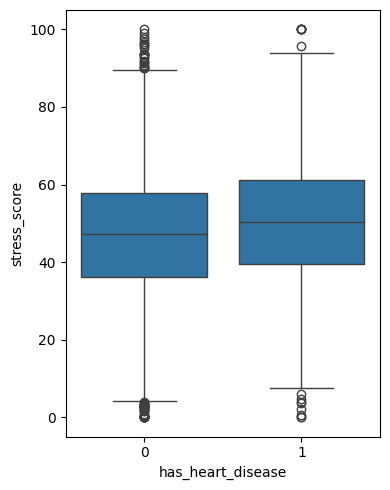

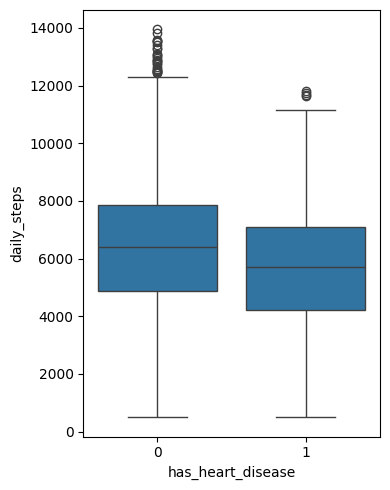

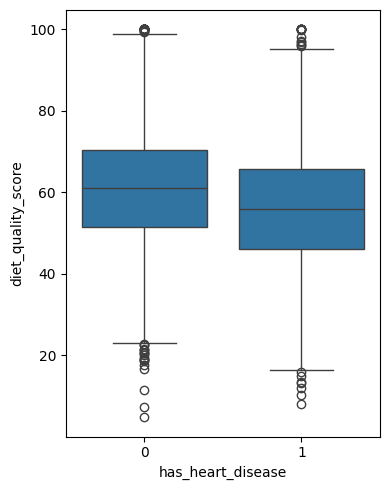

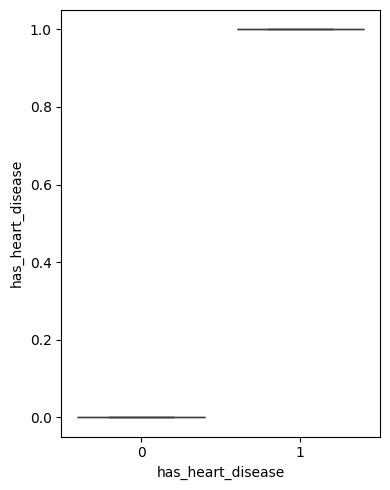

In [15]:
for col in num_cols: 
    plt.figure(figsize=(4,5))
    sns.boxplot(data=df, x='has_heart_disease',y=col)
    plt.tight_layout()

**Age, systolic blood pressure, diastolic blood pressure, maximum heart rate achieved, and a few other variables show noticeable differences in their median values and comparatively less overlap between the two heart disease groups. This suggests that these variables may be useful predictors, which is further verified using inferential statistical tests such as the t-test and chi-square test.**

In [16]:
from scipy.stats import ttest_ind

features = ['age', 'resting_bp_systolic', 'resting_bp_diastolic',
       'cholesterol_total', 'hdl', 'ldl', 'triglycerides',
       'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate',
       'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week',
       'exercise_minutes_per_week', 'sleep_hours', 'stress_score',
       'daily_steps', 'diet_quality_score']

for feature in features:
    group0 = df[df['has_heart_disease'] == 0][feature]
    group1 = df[df['has_heart_disease'] == 1][feature]

    t_stat, p_value = ttest_ind(group0, group1)

    print(f"\n{feature}")
    print(f"t-statistic: {t_stat}")
    print(f"p-value: {p_value}")


age
t-statistic: -28.84725030633058
p-value: 4.290123802170345e-175

resting_bp_systolic
t-statistic: -24.397026456501585
p-value: 2.3646221290920885e-127

resting_bp_diastolic
t-statistic: -18.668800396665638
p-value: 2.430486224337124e-76

cholesterol_total
t-statistic: -16.117974839789632
p-value: 1.2180847426571397e-57

hdl
t-statistic: 24.649500539648454
p-value: 7.065097795303909e-130

ldl
t-statistic: -26.297005731554222
p-value: 6.666104416295961e-147

triglycerides
t-statistic: -10.533318274716027
p-value: 8.567712860084034e-26

fasting_blood_sugar
t-statistic: -19.60073410320681
p-value: 8.393980697823513e-84

hba1c
t-statistic: -21.989755307051826
p-value: 1.963234292195594e-104

bmi
t-statistic: -20.704570659596964
p-value: 4.5481918856549725e-93

resting_heart_rate
t-statistic: -16.186873398974228
p-value: 4.113326564682179e-58

max_heart_rate_achieved
t-statistic: 67.6616081889833
p-value: 0.0

st_depression
t-statistic: -36.23191140302817
p-value: 1.913158426012893e-268

**In the conducted t-test, all of the variables have a p value of less than 0.05, hence the null hypothesis is rejected for all of them, all of the variables differ significantly between the two groups.**

In [17]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['smoker_status'], df['has_heart_disease'])
chi2, p, dof, expected = chi2_contingency(table)

print("Smoker Status")
print("Chi2:", chi2)
print("P-value:", p)

table = pd.crosstab(df['wearable_owner'], df['has_heart_disease'])
chi2, p, dof, expected = chi2_contingency(table)

print("\nWearable Owner")
print("Chi2:", chi2)
print("P-value:", p)

Smoker Status
Chi2: 254.67942406578834
P-value: 4.9781243063287395e-56

Wearable Owner
Chi2: 80.21762494863762
P-value: 3.3536246822571833e-19


**The p value for this chi square test between smoker status, wearable owner and has heart disease, is less than 0.05, hence the null hypothesis is rejected. The variables smoker status, wearable owner differs significantly between different groups.**

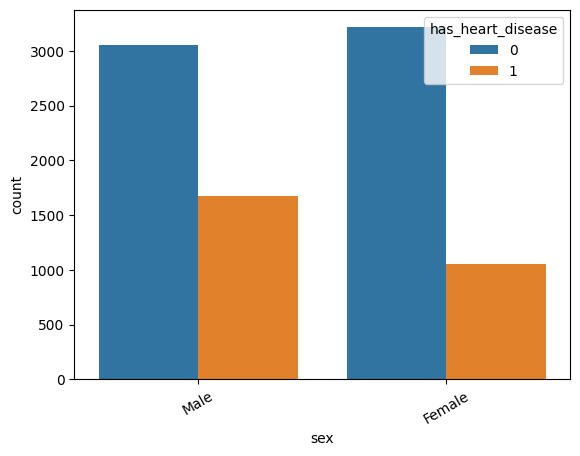

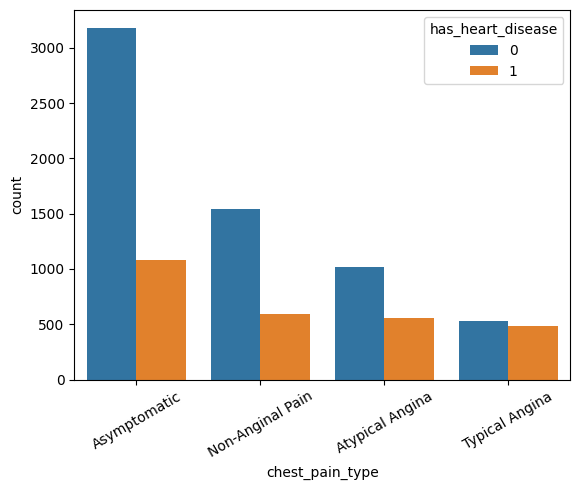

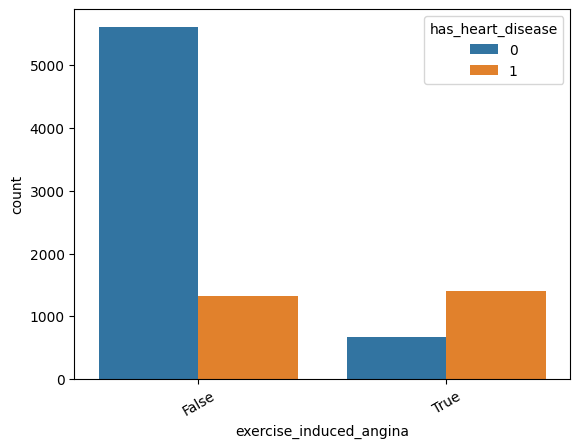

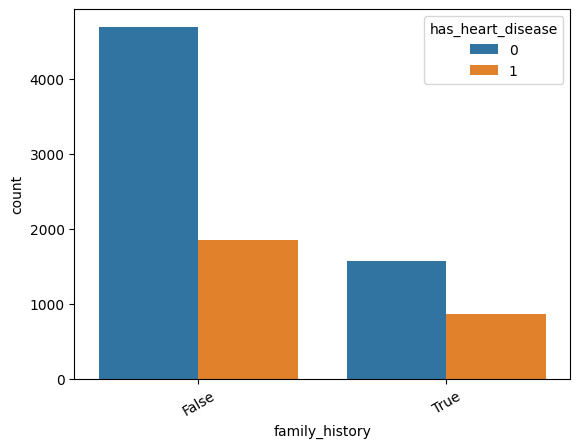

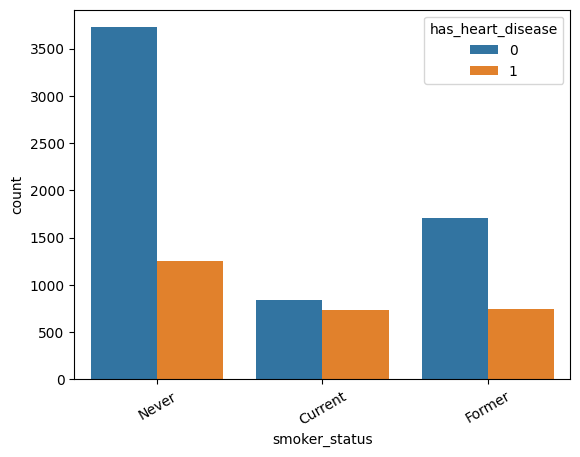

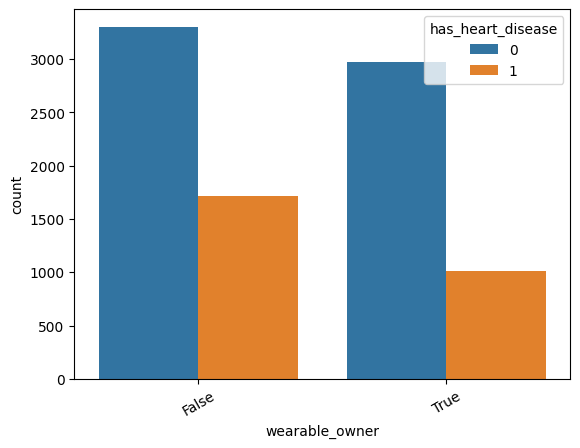

In [18]:
for col in cat_cols:
    sns.countplot(data=df,x=col,hue="has_heart_disease")
    plt.xticks(rotation=30)
    plt.show()

In [19]:
corr=df.corr(numeric_only=True)
corr['has_heart_disease'].sort_values(ascending=False)

has_heart_disease            1.000000
exercise_induced_angina      0.445412
st_depression                0.356817
age                          0.290954
ldl                          0.267150
resting_bp_systolic          0.249089
hba1c                        0.225830
bmi                          0.213249
fasting_blood_sugar          0.202358
resting_bp_diastolic         0.193104
resting_heart_rate           0.168212
cholesterol_total            0.167516
triglycerides                0.110365
stress_score                 0.097975
family_history               0.070622
alcohol_units_per_week       0.041271
sleep_hours                 -0.049797
wearable_owner              -0.094652
daily_steps                 -0.152855
diet_quality_score          -0.155234
exercise_minutes_per_week   -0.248475
hdl                         -0.251505
max_heart_rate_achieved     -0.580704
Name: has_heart_disease, dtype: float64

<Axes: >

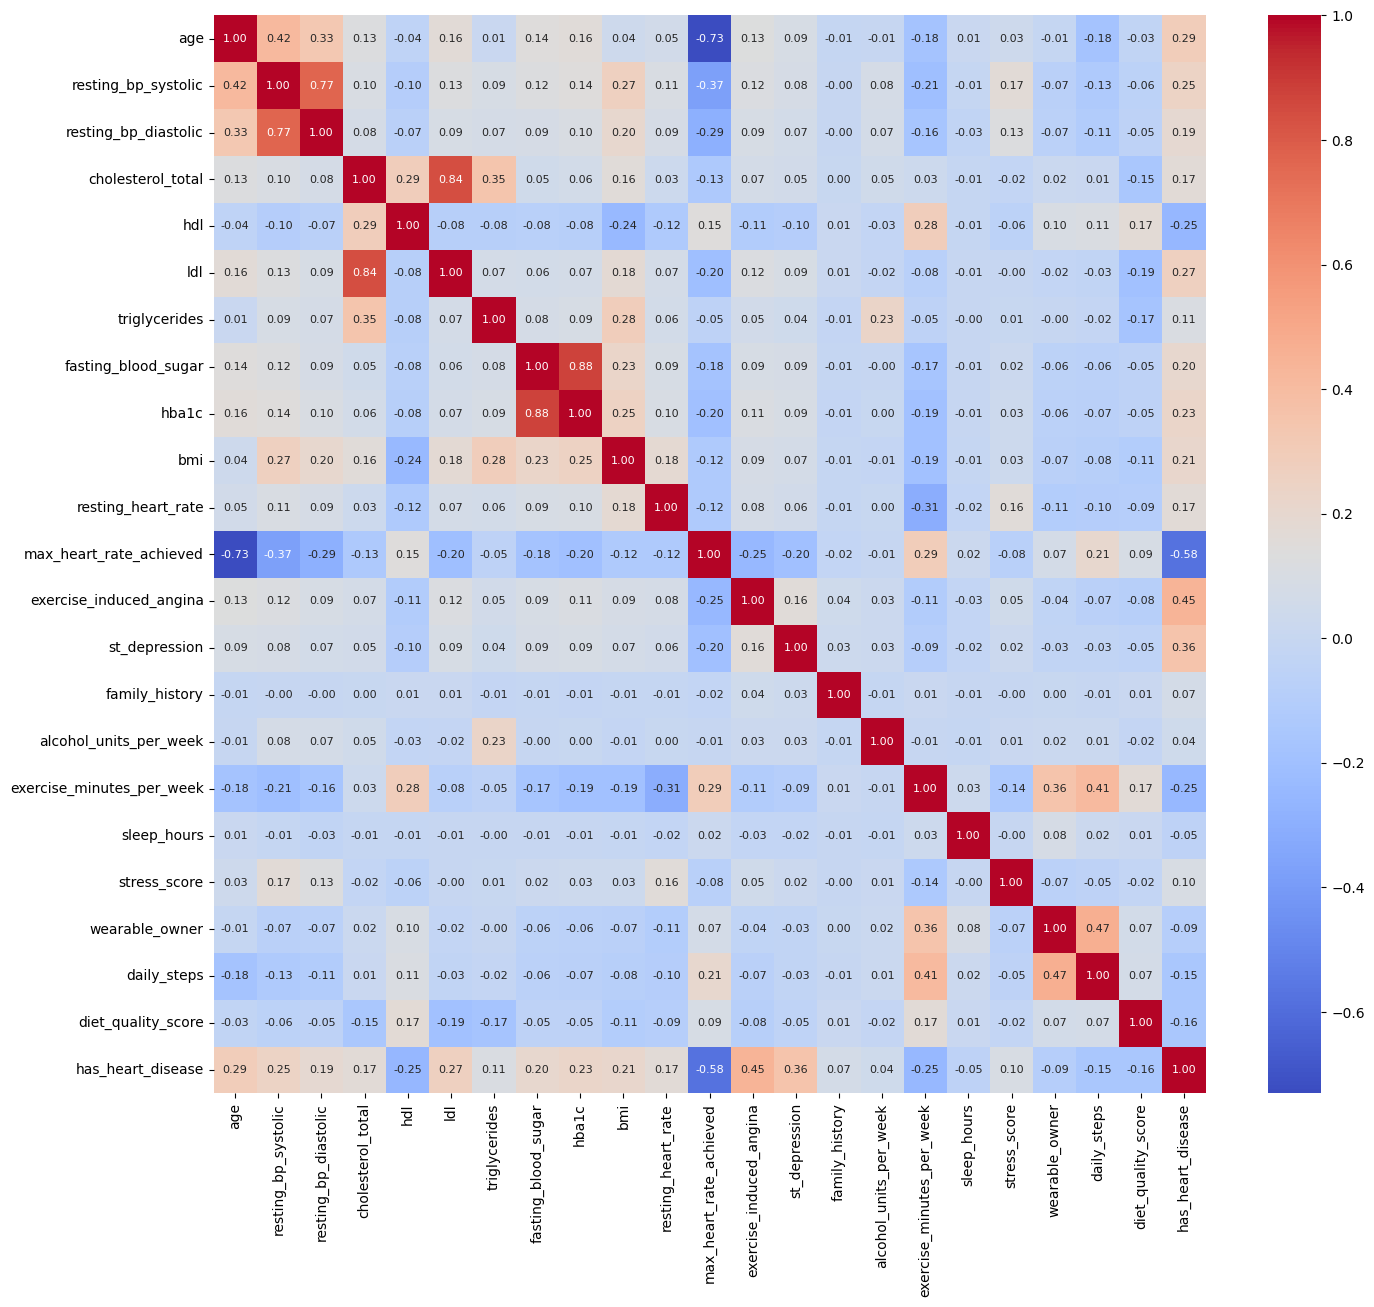

In [20]:
plt.figure(figsize=(16,14))
sns.heatmap(df.corr(numeric_only=True), annot=True,fmt=".2f",cmap="coolwarm",annot_kws={"size":8})

In [21]:
columns = ['age', 'resting_bp_systolic', 'resting_bp_diastolic',
       'cholesterol_total', 'hdl', 'ldl', 'triglycerides',
       'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate',
       'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week',
       'exercise_minutes_per_week', 'sleep_hours', 'stress_score',
       'daily_steps', 'diet_quality_score', 'has_heart_disease']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if lower<0:
        lower=0
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Normal range: {lower:.2f} to {upper:.2f}")
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

age
Normal range: 18.00 to 90.00
Outliers: 0 (0.00%)

resting_bp_systolic
Normal range: 92.00 to 164.00
Outliers: 66 (0.73%)

resting_bp_diastolic
Normal range: 53.00 to 109.00
Outliers: 75 (0.83%)

cholesterol_total
Normal range: 101.00 to 277.00
Outliers: 50 (0.56%)

hdl
Normal range: 21.50 to 89.50
Outliers: 63 (0.70%)

ldl
Normal range: 29.50 to 177.50
Outliers: 34 (0.38%)

triglycerides
Normal range: 13.50 to 289.50
Outliers: 42 (0.47%)

fasting_blood_sugar
Normal range: 57.50 to 181.50
Outliers: 32 (0.36%)

hba1c
Normal range: 3.80 to 7.80
Outliers: 10 (0.11%)

bmi
Normal range: 13.45 to 37.05
Outliers: 39 (0.43%)

resting_heart_rate
Normal range: 57.00 to 105.00
Outliers: 42 (0.47%)

max_heart_rate_achieved
Normal range: 105.00 to 225.00
Outliers: 17 (0.19%)

st_depression
Normal range: 0.00 to 2.90
Outliers: 485 (5.39%)

alcohol_units_per_week
Normal range: 0.00 to 15.95
Outliers: 431 (4.79%)

exercise_minutes_per_week
Normal range: 0.00 to 313.50
Outliers: 27 (0.30%)

sleep_ho

**Outliers were retained because the dataset contains genuine medical measurements. Extreme observations may represent patients with severe conditions rather than data entry errors, making them potentially valuable for model training.**

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        9000 non-null   int64  
 1   sex                        9000 non-null   object 
 2   resting_bp_systolic        9000 non-null   int64  
 3   resting_bp_diastolic       9000 non-null   int64  
 4   cholesterol_total          9000 non-null   int64  
 5   hdl                        9000 non-null   int64  
 6   ldl                        9000 non-null   int64  
 7   triglycerides              9000 non-null   int64  
 8   fasting_blood_sugar        9000 non-null   int64  
 9   hba1c                      9000 non-null   float64
 10  bmi                        9000 non-null   float64
 11  resting_heart_rate         9000 non-null   int64  
 12  max_heart_rate_achieved    9000 non-null   int64  
 13  chest_pain_type            9000 non-null   objec

In [23]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
cols=['sex','family_history','wearable_owner','exercise_induced_angina']
for col in cols:
    df[col]=label_encoder.fit_transform(df[col])

In [24]:
df=pd.get_dummies(df,columns=['chest_pain_type','smoker_status'],dtype=int)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               9000 non-null   int64  
 1   sex                               9000 non-null   int64  
 2   resting_bp_systolic               9000 non-null   int64  
 3   resting_bp_diastolic              9000 non-null   int64  
 4   cholesterol_total                 9000 non-null   int64  
 5   hdl                               9000 non-null   int64  
 6   ldl                               9000 non-null   int64  
 7   triglycerides                     9000 non-null   int64  
 8   fasting_blood_sugar               9000 non-null   int64  
 9   hba1c                             9000 non-null   float64
 10  bmi                               9000 non-null   float64
 11  resting_heart_rate                9000 non-null   int64  
 12  max_he

## MODEL

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df.drop(columns='has_heart_disease')

y = df['has_heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.9004
Testing Accuracy: 0.9094

Confusion Matrix:
[[1178   66]
 [  97  459]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1244
           1       0.87      0.83      0.85       556

    accuracy                           0.91      1800
   macro avg       0.90      0.89      0.89      1800
weighted avg       0.91      0.91      0.91      1800



In [27]:
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report 
X=df.drop(columns='has_heart_disease') 
y=df['has_heart_disease'] 
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=60) 
for depth in [3,4,5,6,7,8,10,None]:
    for leaf in [1, 2, 5, 10]:
         regressor= DecisionTreeClassifier(criterion='gini',max_depth=depth,min_samples_leaf=leaf,class_weight='balanced',random_state=60)
         regressor.fit(X_train, y_train) 
         y_pred=regressor.predict(X_test) 
         train_accuracy=regressor.score(X_train, y_train) 
         test_accuracy=regressor.score(X_test, y_test) 
         print(f"Training Accuracy is: {train_accuracy}") 
         print(f"Test Accuracy is: {test_accuracy}") 
         print("Confusion Matrix") 
         print(confusion_matrix(y_test,y_pred)) 
         print("Classification Report") 
         print(classification_report(y_test,y_pred))
         print("--------------------------------------------------------------")

Training Accuracy is: 0.8393055555555555
Test Accuracy is: 0.8255555555555556
Confusion Matrix
[[1107  152]
 [ 162  379]]
Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1259
           1       0.71      0.70      0.71       541

    accuracy                           0.83      1800
   macro avg       0.79      0.79      0.79      1800
weighted avg       0.82      0.83      0.83      1800

--------------------------------------------------------------
Training Accuracy is: 0.8393055555555555
Test Accuracy is: 0.8255555555555556
Confusion Matrix
[[1107  152]
 [ 162  379]]
Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1259
           1       0.71      0.70      0.71       541

    accuracy                           0.83      1800
   macro avg       0.79      0.79      0.79      1800
weighted avg       0.82      0.83      0.83      1

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10, 20]
}

grid = GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced',random_state=60),
    param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
0.7498111273676384
[[1053  206]
 [  95  446]]
              precision    recall  f1-score   support

           0       0.92      0.84      0.87      1259
           1       0.68      0.82      0.75       541

    accuracy                           0.83      1800
   macro avg       0.80      0.83      0.81      1800
weighted avg       0.85      0.83      0.84      1800



In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10, 20],
}

grid = GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced',random_state=60),
    param_grid=param_grid,cv=5,scoring='precision',n_jobs=-1)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.7526019953175047
[[1140  119]
 [ 169  372]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1259
           1       0.76      0.69      0.72       541

    accuracy                           0.84      1800
   macro avg       0.81      0.80      0.80      1800
weighted avg       0.84      0.84      0.84      1800



In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {'criterion': ['gini', 'entropy'],'max_depth': [3, 5, 7, 10, None],'min_samples_leaf': [1, 2, 5, 10],
              'min_samples_split': [2, 5, 10, 20]}

grid = GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced',random_state=60),
    param_grid=param_grid,cv=5,scoring='recall',n_jobs=-1)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
0.8572782462409746
[[1029  230]
 [  85  456]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1259
           1       0.66      0.84      0.74       541

    accuracy                           0.82      1800
   macro avg       0.79      0.83      0.81      1800
weighted avg       0.85      0.82      0.83      1800



| Metric Optimized | Accuracy | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) |
| ---------------- | :------: | :-----------------: | :--------------: | :----------: |
| **Recall**       |   0.82   |         0.66        |     **0.84**     |     0.74     |
| **F1**           |   0.83   |         0.68        |       0.82       |   **0.75**   |
| **Precision**    | **0.84** |       **0.76**      |       0.69       |     0.72     |


Recall optimization

* Highest recall (84%)
* Lowest precision (66%)
* Catches more heart disease patients
* More false alarms (230 FP)

Precision optimization

* Highest precision (76%)
* Lowest recall (69%)
* Fewer false positives
* Misses more heart disease patients (169 FN)

F1 optimization

* Best balance
* Accuracy increased to 83%
* Precision improved to 68%
* Recall remained high at 82%
* Highest Class 1 F1-score (75%)

**Different hyperparameter tuning for different objectives give us different results which are more or less a trade off between precision and recall at every stage. F1-score achieved the best balance between correctly identifying heart disease cases and minimizing incorrect positive predictions, making it the final selected model.**

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dist={'criterion':['gini','entropy'],'max_depth':[3,5,7,10,None],'min_samples_leaf':[1,2,5,10]
           ,'min_samples_split':[2,5,10,20]}
random_search=RandomizedSearchCV(DecisionTreeClassifier(class_weight='balanced',random_state=60),
                                 param_distributions=param_dist
                         ,n_iter=20,random_state=60,cv=5,scoring='f1',n_jobs=-1)
random_search.fit(X_train,y_train)
print(random_search.best_params_)
print(random_search.best_score_)

best_model=random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 5, 'criterion': 'gini'}
0.748324905322997
[[1029  230]
 [  85  456]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1259
           1       0.66      0.84      0.74       541

    accuracy                           0.82      1800
   macro avg       0.79      0.83      0.81      1800
weighted avg       0.85      0.82      0.83      1800



In [32]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

def objective(trial):
    model = DecisionTreeClassifier(
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        class_weight="balanced",
        random_state=60)

    score = cross_val_score(model,X_train,y_train,cv=5,scoring="f1").mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(study.best_params)
print(study.best_value)
best_model=random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[I 2026-08-05 11:00:05,617] A new study created in memory with name: no-name-c060af12-477f-43b7-adca-eef055fe0159
[I 2026-08-05 11:00:06,188] Trial 0 finished with value: 0.6917757034343326 and parameters: {'criterion': 'gini', 'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 3}. Best is trial 0 with value: 0.6917757034343326.
[I 2026-08-05 11:00:06,516] Trial 1 finished with value: 0.7501234947096245 and parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 9}. Best is trial 1 with value: 0.7501234947096245.
[I 2026-08-05 11:00:06,950] Trial 2 finished with value: 0.744326011244512 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 8, 'min_samples_split': 8}. Best is trial 1 with value: 0.7501234947096245.
[I 2026-08-05 11:00:07,217] Trial 3 finished with value: 0.7420476494965331 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 18, 'min_samples_split': 18}. Best is trial 1 wit

{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 19, 'min_samples_split': 5}
0.7586484637274784
[[1029  230]
 [  85  456]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1259
           1       0.66      0.84      0.74       541

    accuracy                           0.82      1800
   macro avg       0.79      0.83      0.81      1800
weighted avg       0.85      0.82      0.83      1800




**Best Hyperparameters: Criterion: Entropy, Max Depth: 9, Min Samples Split: 14, Min Samples Leaf: 19**


**We tested multiple methods of hyper-parameter tuning by also focusing on different goals such as recall, precision, f1 etc. But our main focus is on the f1 score as the dataset itself is imbalanced.**

**A Decision Tree Classifier was trained to predict heart disease. Hyperparameter tuning using GridSearchCV, RandomSearchCV and Bayesian Optimization improved the model, with the F1-optimized model providing the best balance between precision and recall. The final model achieved approximately 83% test accuracy while still having a trade off between false positives and false negatives.**